# Notebook 03 — Model A vs Model B

## What this notebook is about

The paper defines **two** formulations of the market making problem. Both lead to the **same family of ODEs** (Eq. 3.9), differing only in a single parameter $\xi$:

| | **Model A** | **Model B** |
|---|---|---|
| **Objective** | $\max\; \mathbb{E}\!\big[-e^{-\gamma(X_T + q_T S_T)}\big]$ | $\max\; \mathbb{E}\!\big[X_T + q_T S_T - \tfrac{1}{2}\gamma\sigma^2\!\int_0^T q_t^2\,dt\big]$ |
| **Paper Eq.** | Eq. 2.5 → HJB Eq. 3.1 | Eq. 2.6 → HJB Eq. 3.5 |
| **Risk treatment** | CARA utility on terminal wealth | Mean-variance with running inventory penalty |
| **Ansatz** | $u = -\exp\!\big(-\gamma(x + qS + \theta)\big)$ (Eq. 3.3) | $u = x + qS + \theta(t,q)$ (Eq. 3.7) |
| **ODE parameter** | $\xi = \gamma$ | $\xi = 0$ |
| **Risk aversion to** | Price risk **+** non-execution risk | Price risk **only** |

**Key insight** (Paper §3.4, p. 16):
> *"The parameter $\xi$ can be regarded as some form of risk aversion parameter applying to non-execution risk only: it is equal to $\gamma$ in the case of Model A, and equal to 0 in the case of Model B."*

## 1. How $\xi$ enters the equations

Both models reduce to the **same** ODE (Eq. 3.9):

$$\partial_t \theta + \tfrac{1}{2}\gamma\sigma^2 q^2 - \mathbb{1}_{q<Q}\,H_\xi\!\left(\frac{\theta(t,q) - \theta(t,q+\Delta)}{\Delta}\right) - \mathbb{1}_{q>-Q}\,H_\xi\!\left(\frac{\theta(t,q) - \theta(t,q-\Delta)}{\Delta}\right) = 0$$

The parameter $\xi$ only affects two things:

- The Hamiltonian $H_\xi$ (after Eq. 3.9)

$$H_\xi(p) = \frac{A\Delta}{k}\,C_\xi\,e^{-kp}$$

The coefficient $C_\xi$ changes:

| | $C_\xi$ | Numerical value (IG) |
|---|---|---|
| **Model A** ($\xi = \gamma$) | $\left(1 + \frac{\gamma\Delta}{k}\right)^{-(k/(\gamma\Delta)+1)}$ | $C_{3000} \approx$ very small |
| **Model B** ($\xi = 0$) | $e^{-1} \approx 0.3679$ | $0.3679$ |

- The quote extraction formula $\tilde{\delta}^*$ (Eqs. 3.14 / 3.16)

$$\tilde{\delta}^*_\xi(p) = \begin{cases} p + \frac{1}{\xi\Delta}\ln\!\left(1 + \frac{\xi\Delta}{k}\right) & \xi > 0 \quad \text{(Model A)} \\ p + \frac{1}{k} & \xi = 0 \quad \text{(Model B)} \end{cases}$$

So the **static half-spread** differs:
- Model A: $\delta_{\text{static}} = \frac{1}{\gamma\Delta}\ln(1 + \gamma\Delta/k)$
- Model B: $\delta_{\text{static}} = 1/k$

Despite these differences, the paper shows numerically that the resulting quotes are nearly identical.


## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.params.assets import IG, HY, GAMMA, T
from market_making.core.solver_1d import solve_general
from market_making.core.intensity import C_coeff, delta_star

plt.style.use("seaborn-v0_8")
%matplotlib inline

## 3. Parameters

Same IG / HY parameters as Notebooks 01–02. The only change is $\xi$:
- **Model A**: $\xi = \gamma = 6 \times 10^{-5}$
- **Model B**: $\xi = 0$

Let's compute the key derived quantities for both models to see how much they actually differ.


In [2]:
print(f"{'Quantity':<25s}  {'IG (A)':>12s}  {'IG (B)':>12s}  {'HY (A)':>12s}  {'HY (B)':>12s}")
print("─" * 78)

for name, p in [("IG", IG), ("HY", HY)]:
    # Model A
    xD_a = GAMMA * p["Delta"]
    C_a = C_coeff(xD_a, p["k"])
    d_static_a = (1.0 / xD_a) * np.log(1.0 + xD_a / p["k"])
    
    # Model B
    C_b = C_coeff(0.0, p["k"])  # = e^{-1}
    d_static_b = 1.0 / p["k"]
    
    if name == "IG":
        vals_a = [f"{xD_a:.0f}", f"{C_a:.6e}", f"{d_static_a:.6e}"]
        vals_b = ["0", f"{C_b:.6e}", f"{d_static_b:.6e}"]
    else:
        vals_a2 = [f"{xD_a:.0f}", f"{C_a:.6e}", f"{d_static_a:.6e}"]
        vals_b2 = ["0", f"{C_b:.6e}", f"{d_static_b:.6e}"]

labels = ["ξΔ", "C_ξ", "δ_static"]
for i, lab in enumerate(labels):
    print(f"{lab:<25s}  {vals_a[i]:>12s}  {vals_b[i]:>12s}  {vals_a2[i]:>12s}  {vals_b2[i]:>12s}")
print("─" * 78)
print()
# Relative difference in δ_static
for name, p in [("IG", IG), ("HY", HY)]:
    xD = GAMMA * p["Delta"]
    ds_a = (1.0 / xD) * np.log(1.0 + xD / p["k"])
    ds_b = 1.0 / p["k"]
    print(f"\n{name}: |δ_static_A − δ_static_B| / δ_static_A = "
          f"{abs(ds_a - ds_b)/ds_a:.2%}")


Quantity                         IG (A)        IG (B)        HY (A)        HY (B)
──────────────────────────────────────────────────────────────────────────────
ξΔ                                 3000             0           600             0
C_ξ                        3.397741e-01  3.678794e-01  3.489096e-01  3.678794e-01
δ_static                   5.164948e-05  5.586592e-05  1.734666e-04  1.828154e-04
──────────────────────────────────────────────────────────────────────────────


IG: |δ_static_A − δ_static_B| / δ_static_A = 8.16%

HY: |δ_static_A − δ_static_B| / δ_static_A = 5.39%


## 4. Solve the ODE for both models (Eq. 3.9)

We run `solve_general` four times: IG × {A, B} and HY × {A, B}.

Both use the **same Newton solver** (implicit Euler + Newton iteration). The only parameter that changes between Model A and Model B is the value of `xi` passed to the solver:
- `xi=GAMMA` → Model A ($\xi = \gamma$, Theorem 3.2)
- `xi=0.0` → Model B ($\xi = 0$, Theorem 3.3)


In [3]:
N_T = 7200

# Solving IG Model A (ξ = γ)
t0 = time.time()
sol_ig_a = solve_general(IG, GAMMA, T, xi=GAMMA, N_t=N_T)

In [4]:
# Solving IG Model B (ξ = 0)
t0 = time.time()
sol_ig_b = solve_general(IG, GAMMA, T, xi=0.0, N_t=N_T)

In [5]:
# Solving HY Model A (ξ = γ)
t0 = time.time()
sol_hy_a = solve_general(HY, GAMMA, T, xi=GAMMA, N_t=N_T)

In [6]:
# Solving HY Model B (ξ = 0)
t0 = time.time()
sol_hy_b = solve_general(HY, GAMMA, T, xi=0.0, N_t=N_T)

## 5. Figures 8–9 (IG) and 15–16 (HY) — Model A vs Model B

**Paper reference** (p. 35, IG):
> *"We see in Figures 8 and 9 that the differences between the two models is in fact very small. In other words, although Model B ignores part of the risk (or more precisely aversion to part of the risk), it constitutes a very interesting simplification of Model A."*

**Paper reference** (p. 38, HY):
> *"As far as the comparison between Model A and Model B are concerned, we see in Figures 15 and 16 that the differences between the two models is very small, as in the case of the IG index."*

Each figure overlays:
- **Crosses (×)**: Model A quotes ($\xi = \gamma$)
- **Circles (○)**: Model B quotes ($\xi = 0$)


In [7]:
def compare_ab(sol_a, sol_b, params, label, fig_nums):
    """Compare quotes at t = 0 for Model A vs B.    
    Reproduces Paper Figs 8-9 (IG) / 15-16 (HY).
    """
    lots = sol_a["lots"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Bid (Paper Fig 8 / 15) ──
    ax = axes[0]
    db_a = sol_a["delta_bid"][0, :]
    db_b = sol_b["delta_bid"][0, :]
    mask_a = np.isfinite(db_a)
    mask_b = np.isfinite(db_b)
    ax.plot(lots[mask_a], db_a[mask_a], "x", ms=9, color="C0", mew=2, label="Model A (ξ=γ)")
    ax.plot(lots[mask_b], db_b[mask_b], "o", ms=7, mfc="none", mew=2, color="C1", label="Model B (ξ=0)")
    ax.set_title(f"Fig {fig_nums[0]}: {label} — δ^bid(0, n)", fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^bid ($/upfront)")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Ask (Paper Fig 9 / 16) ──
    ax = axes[1]
    da_a = sol_a["delta_ask"][0, :]
    da_b = sol_b["delta_ask"][0, :]
    mask_a = np.isfinite(da_a)
    mask_b = np.isfinite(da_b)
    ax.plot(lots[mask_a], da_a[mask_a], "x", ms=9, color="C0", mew=2, label="Model A (ξ=γ)")
    ax.plot(lots[mask_b], da_b[mask_b], "o", ms=7, mfc="none", mew=2, color="C1", label="Model B (ξ=0)")
    ax.set_title(f"Fig {fig_nums[1]}: {label} — δ^ask(0, n)", fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^ask ($/upfront)")
    ax.legend()
    ax.grid(alpha=0.3)

    fig.suptitle(f"Model A vs B — {label}", fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

    # ── Quantify difference ──
    mask = np.isfinite(db_a) & np.isfinite(db_b)
    max_diff_bid = np.max(np.abs(db_a[mask] - db_b[mask]))
    rel_diff_bid = max_diff_bid / np.mean(np.abs(db_a[mask]))
    print(f"  {label}: max |δ^b_A − δ^b_B| = {max_diff_bid:.4e}  "
          f"(relative: {rel_diff_bid:.2%})")


### 5.1 IG — Figures 8–9

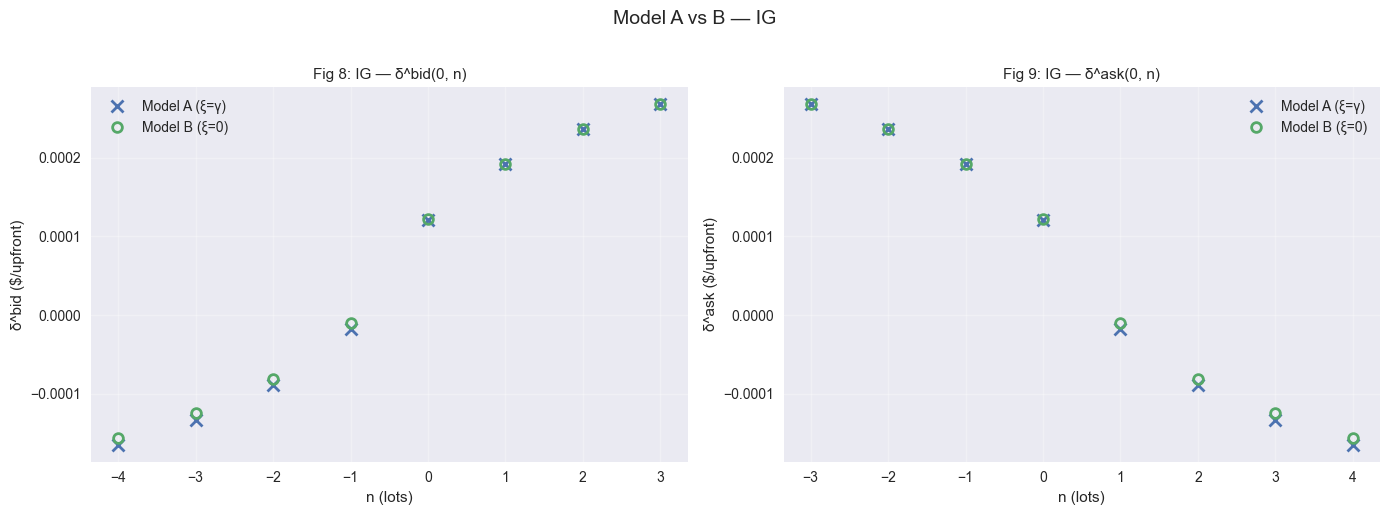

  IG: max |δ^b_A − δ^b_B| = 8.5554e-06  (relative: 5.61%)


In [8]:
compare_ab(sol_ig_a, sol_ig_b, IG, "IG", fig_nums=(8, 9))

### 5.2 HY — Figures 15–16

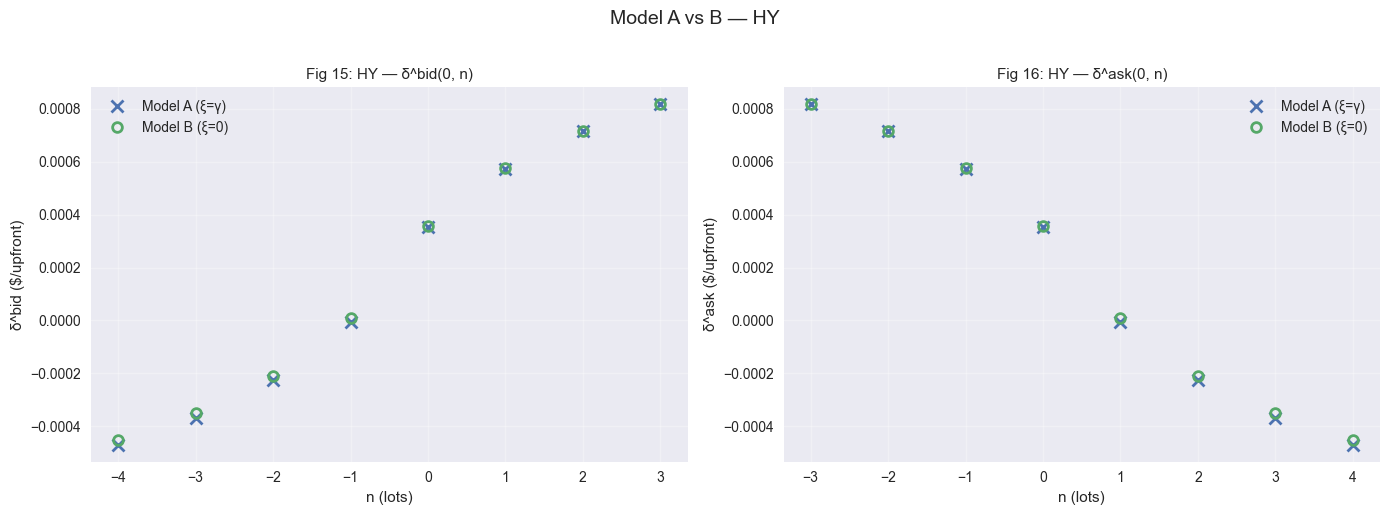

  HY: max |δ^b_A − δ^b_B| = 1.8663e-05  (relative: 4.24%)


In [9]:
compare_ab(sol_hy_a, sol_hy_b, HY, "HY", fig_nums=(15, 16))

| Paper Fig | Content | Key observation |
|-----------|---------|-----------------|
| Fig 8 | IG $\delta^b(0,n)$: A (×) vs B (○) | Nearly indistinguishable |
| Fig 9 | IG $\delta^a(0,n)$: A (×) vs B (○) | Nearly indistinguishable |
| Fig 15 | HY $\delta^b(0,n)$: A (×) vs B (○) | Nearly indistinguishable |
| Fig 16 | HY $\delta^a(0,n)$: A (×) vs B (○) | Nearly indistinguishable |

### Key result

Model B ($\xi = 0$) is an excellent approximation of Model A ($\xi = \gamma$).

**Why this matters for practitioners** (Paper §3.4):
- Model B is simpler to interpret (mean-variance, running penalty).
- Model B is used in the Cartea–Jaimungal framework and most applied work.
- The paper validates it as a *"very interesting simplification"* (p. 35).


## A.2 Quantitative error table — A vs B

Pointwise comparison across all valid inventory levels, for bid, ask, spread, and skew.


In [10]:

def full_error_table(sol_a, sol_b, params, label):
    Q = int(params["Q"])
    lots = sol_a["lots"]
    
    print(f"\n  === {label} ===")
    print(f"  {'Quantity':<20s}  {'max|A-B|':>12s}  {'mean|A-B|':>12s}" ) #{'max rel':>10s}  {'mean rel':>10s}")
    print("  " + "─" * 50)
    
    for name, arr_a, arr_b in [
        ("δ^bid",  sol_a["delta_bid"][0,:], sol_b["delta_bid"][0,:]),
        ("δ^ask",  sol_a["delta_ask"][0,:], sol_b["delta_ask"][0,:]),
        ("Spread", sol_a["delta_bid"][0,:]+sol_a["delta_ask"][0,:],
                   sol_b["delta_bid"][0,:]+sol_b["delta_ask"][0,:]),
        ("Skew",   sol_a["delta_bid"][0,:]-sol_a["delta_ask"][0,:],
                   sol_b["delta_bid"][0,:]-sol_b["delta_ask"][0,:]),
    ]:
        mask = np.isfinite(arr_a) & np.isfinite(arr_b)
        if not np.any(mask):
            continue
        abs_err = np.abs(arr_a[mask] - arr_b[mask])
        denom = np.abs(arr_a[mask])
        denom[denom == 0] = 1e-30  # avoid division by zero for skew at n=0
        rel_err = abs_err / denom
        print(f"  {name:<20s}  {abs_err.max():>12.4e}  {abs_err.mean():>12.4e}  ")
              #f"{rel_err.max():>9.2%}  {rel_err.mean():>9.2%}")

full_error_table(sol_ig_a, sol_ig_b, IG, "IG")
full_error_table(sol_hy_a, sol_hy_b, HY, "HY")



  === IG ===
  Quantity                  max|A-B|     mean|A-B|
  ──────────────────────────────────────────────────
  δ^bid                   8.5554e-06    4.2603e-06  
  δ^ask                   8.5554e-06    4.2603e-06  
  Spread                  8.3634e-06    7.1932e-06  
  Skew                    8.6085e-06    6.9451e-06  

  === HY ===
  Quantity                  max|A-B|     mean|A-B|
  ──────────────────────────────────────────────────
  δ^bid                   1.8663e-05    9.3487e-06  
  δ^ask                   1.8663e-05    9.3487e-06  
  Spread                  1.8456e-05    1.6036e-05  
  Skew                    1.8388e-05    1.4365e-05  


## A.3 Why are the two models so close?

The difference between Model A and B lives entirely in $C_\xi$:

$$\frac{C_{\gamma\Delta}}{C_0} = \frac{\left(1 + \frac{\gamma\Delta}{k}\right)^{-(k/(\gamma\Delta)+1)}}{e^{-1}}$$

When $\gamma\Delta / k$ is small, we can expand:

$$\ln C_{\gamma\Delta} = -\left(\frac{k}{\gamma\Delta} + 1\right)\ln\!\left(1 + \frac{\gamma\Delta}{k}\right) \approx -1 - \frac{\gamma\Delta}{2k} + O\!\left(\frac{\gamma\Delta}{k}\right)^2$$

So $C_{\gamma\Delta} \approx e^{-1} \cdot e^{-\gamma\Delta/(2k)} \approx C_0$ when $\gamma\Delta \ll k$.

Let's check this ratio for our parameters.


In [11]:
for name, p in [("IG", IG), ("HY", HY)]:
    xD = GAMMA * p["Delta"]
    C_a = C_coeff(xD, p["k"])
    C_b = C_coeff(0.0, p["k"])
    ratio = C_a / C_b
    
    # First-order correction
    approx_ratio = np.exp(-xD / (2 * p["k"]))
    
    print(f"{name}:  γΔ/k = {xD/p['k']:.4f}  →  C_A/C_B = {ratio:.6f}  "
          f"(1st-order approx: {approx_ratio:.6f})")

print("\nBoth ratios ≈ 1 → explains why quotes are nearly identical.")
print("The difference is O(γΔ/k), which is small for both assets.")


IG:  γΔ/k = 0.1676  →  C_A/C_B = 0.923602  (1st-order approx: 0.919616)
HY:  γΔ/k = 0.1097  →  C_A/C_B = 0.948434  (1st-order approx: 0.946632)

Both ratios ≈ 1 → explains why quotes are nearly identical.
The difference is O(γΔ/k), which is small for both assets.


## A.4 Spread and skew — A vs B

The paper only shows bid and ask overlays (Figs 8–9, 15–16). Let's also compare spread and skew, which are the quantities practitioners actually use.


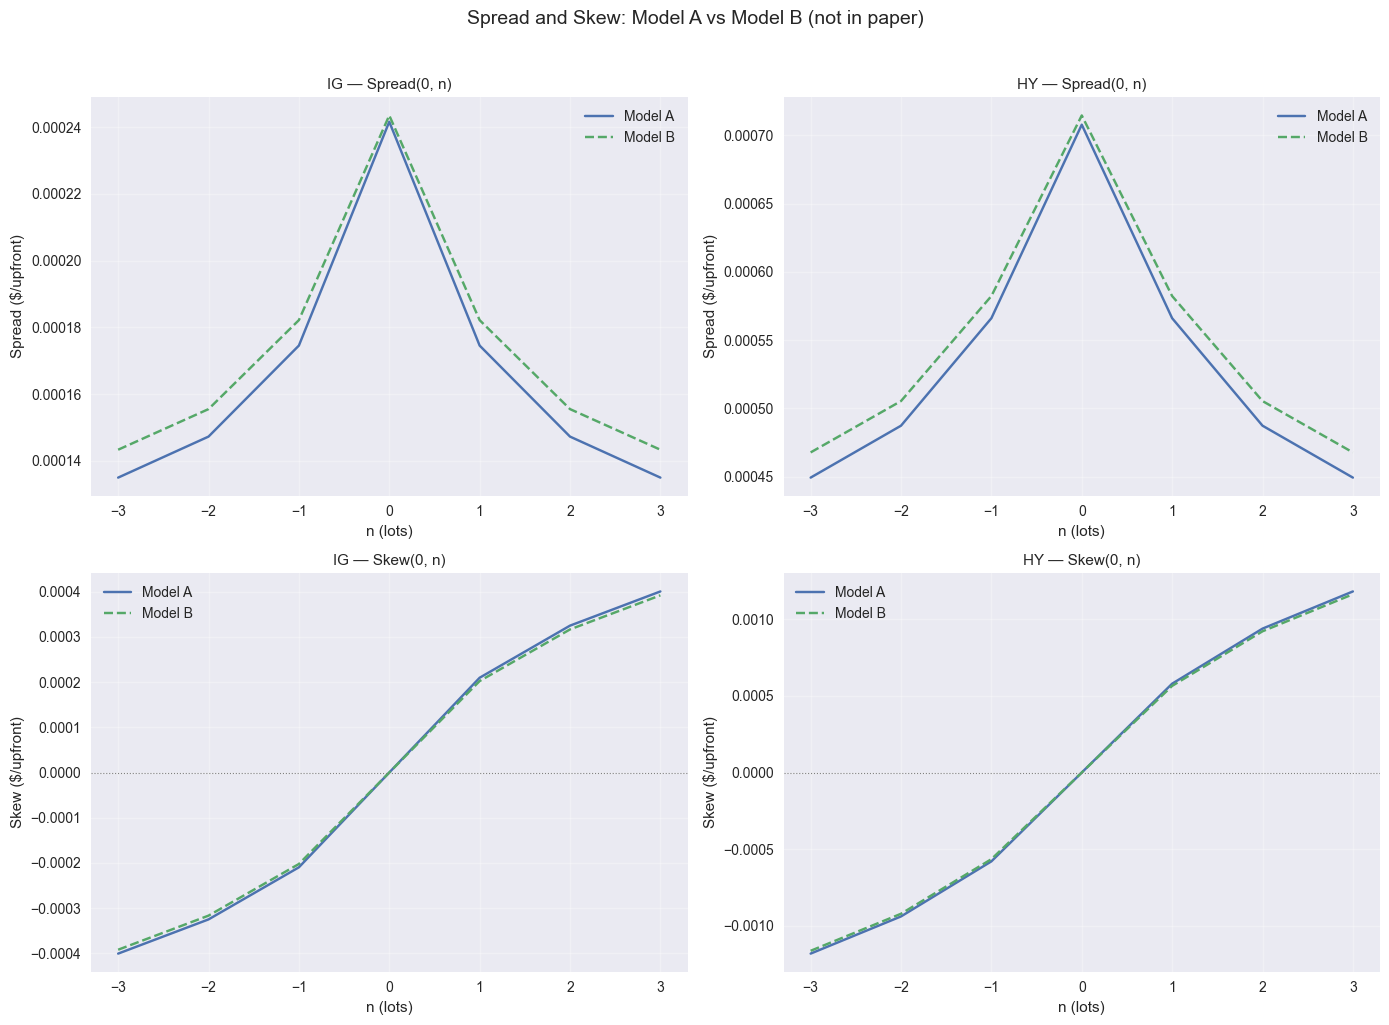

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (sol_a, sol_b, params, name) in enumerate([
    (sol_ig_a, sol_ig_b, IG, "IG"),
    (sol_hy_a, sol_hy_b, HY, "HY"),
]):
    lots = sol_a["lots"]
    
    spread_a = sol_a["delta_bid"][0,:] + sol_a["delta_ask"][0,:]
    spread_b = sol_b["delta_bid"][0,:] + sol_b["delta_ask"][0,:]
    skew_a = sol_a["delta_bid"][0,:] - sol_a["delta_ask"][0,:]
    skew_b = sol_b["delta_bid"][0,:] - sol_b["delta_ask"][0,:]
    
    # Spread
    ax = axes[0, col]
    mask = np.isfinite(spread_a) & np.isfinite(spread_b)
    ax.plot(lots[mask], spread_a[mask], "x-", ms=8, label="Model A")
    ax.plot(lots[mask], spread_b[mask], "o--", ms=6, mfc="none", label="Model B")
    ax.set_title(f"{name} — Spread(0, n)", fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("Spread ($/upfront)")
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Skew
    ax = axes[1, col]
    mask = np.isfinite(skew_a) & np.isfinite(skew_b)
    ax.plot(lots[mask], skew_a[mask], "x-", ms=8, label="Model A")
    ax.plot(lots[mask], skew_b[mask], "o--", ms=6, mfc="none", label="Model B")
    ax.set_title(f"{name} — Skew(0, n)", fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("Skew ($/upfront)")
    ax.axhline(0, color="gray", ls=":", lw=0.8)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Spread and Skew: Model A vs Model B (not in paper)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## A.6 Value function $\theta(0,n)$ — A vs B

The quotes are derived from the discrete gradient of $\theta$. Let's compare $\theta$ itself to see if the functions are close or if cancellation effects make the quotes look similar.


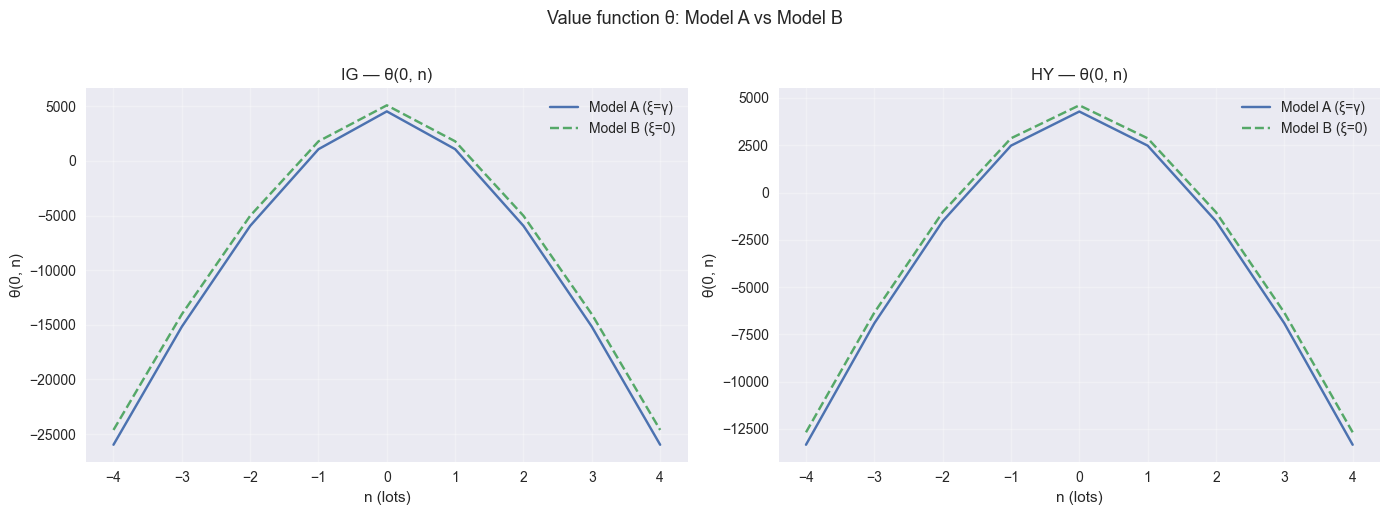

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sol_a, sol_b, params, name in [
    (axes[0], sol_ig_a, sol_ig_b, IG, "IG"),
    (axes[1], sol_hy_a, sol_hy_b, HY, "HY"),
]:
    lots = sol_a["lots"]
    ax.plot(lots, sol_a["theta"][0, :], "x-", ms=8, label="Model A (ξ=γ)")
    ax.plot(lots, sol_b["theta"][0, :], "o--", ms=6, mfc="none", label="Model B (ξ=0)")
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("θ(0, n)")
    ax.set_title(f"{name} — θ(0, n)")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Value function θ: Model A vs Model B", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()
